In [1]:
import torch
import pyro
import pyro.distributions as dist
import os
import matplotlib.pyplot as plt
import sys

/Users/atersenov/miniconda3/envs/jax_gp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from gppyro_emulator.utils import (
    load_training_data,
    load_covariance_matrix,
    load_observed_data
)
from gppyro_emulator.gp_emulator import IndependentGPEmulator
from gppyro_emulator.pyro_model import run_pyro_mcmc

Global variables

In [3]:
# --- Configuration ---
# Define data paths (relative to the project root)
DATA_DIR = "./data"
PARAMS_PATH = os.path.join(DATA_DIR, "parameters.npy")      # Shape: (25, 4)
HIST_PATH = os.path.join(DATA_DIR, "histograms.npy")      # Shape: (25, 48)
COV_PATH = os.path.join(DATA_DIR, "covariance.npy")       # Shape: (48, 48)
# OBS_PATH = os.path.join(DATA_DIR, "observed_histogram.npy") # Shape: (48,)

# GP Training settings
GP_TRAINING_ITERATIONS = 1000 # Increase for better GP convergence
GP_LEARNING_RATE = 0.1
USE_GPU_GP_TRAINING = True

# MCMC settings
NUM_SAMPLES = 100
WARMUP_STEPS = 50
NUM_CHAINS = 1 # Run multiple chains for diagnostics
USE_GPU_MCMC = True # Set to True if GPU is available and desired for MCMC
JIT_COMPILE = False # Can speed up NUTS but might have overhead

Priors & datavectors

In [4]:
# Parameter Priors (Optional - uncomment and adjust if needed)
# Example: Normal priors centered around 0.5 with std dev 0.2
# param_priors = {
#     'param_0': dist.Normal(0.5, 0.2),
#     'param_1': dist.Normal(0.5, 0.2),
#     'param_2': dist.Normal(0.5, 0.2),
#     'param_3': dist.Normal(0.5, 0.2),
# }
# If commented out, defaults to Uniform(0, 1) for each parameter
param_priors = None # Use default Uniform(0, 1) priors

# Parameter names for plotting
PARAM_NAMES = ["Param 0", "Param 1", "Param 2", "Param 3"]

train_params, train_histograms = load_training_data(PARAMS_PATH, HIST_PATH)
covariance_matrix = load_covariance_matrix(COV_PATH)
# observed_histogram = load_observed_data(OBS_PATH)

Initialize GP

In [5]:
# --- 2. Initialize and Train GP Emulator ---
print("\nInitializing GP Emulator...")
emulator = IndependentGPEmulator(num_outputs=48)


Initializing GP Emulator...


Train GP

In [6]:
emulator.train_gps(
    train_params,
    train_histograms,
    training_iterations=GP_TRAINING_ITERATIONS,
    learning_rate=GP_LEARNING_RATE
)

Training GPs on device: cpu
Training 48 independent GPs...
Training complete.


In [7]:
train_params.shape

torch.Size([25, 4])

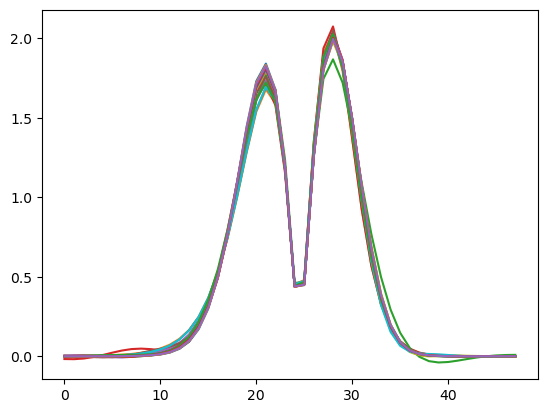

Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points...
Predicting on device: cpu
Predicting for 1 input points.

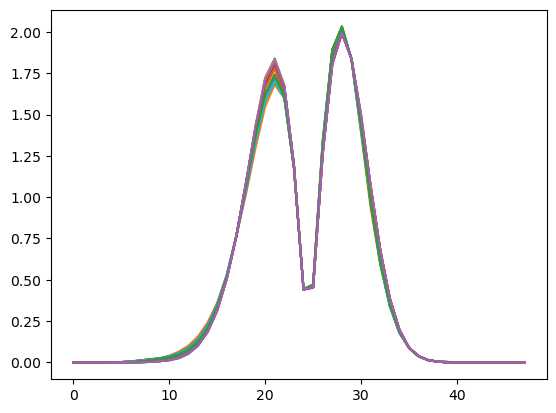

In [8]:
for i in range(25):
    plt.plot(train_histograms[i])
plt.show()

# get the predictions of the emulator at the parameters
for i in range(25):
    predictions = emulator.predict(train_params[i])
    plt.plot(predictions[0])
plt.show()



In [ ]:
# --- 3. Run Pyro MCMC Inference ---
print("\nRunning MCMC Inference...")
mcmc_result = run_pyro_mcmc(
    emulator=emulator,
    covariance_matrix=covariance_matrix,
    observed_histogram=emulator.predict(train_params[i]),
    param_priors=param_priors,
    num_samples=NUM_SAMPLES,
    warmup_steps=WARMUP_STEPS,
    num_chains=NUM_CHAINS,
    use_gpu=USE_GPU_MCMC,
    jit_compile=JIT_COMPILE
)

# --- 4. Process and Visualize Results ---
print("\nProcessing MCMC results...")
mcmc_result.summary()

In [11]:
# --- 4. Process and Visualize Results ---
print("\nProcessing MCMC results...")
mcmc_result.summary()

# Get posterior samples
posterior_samples = mcmc_result.get_samples()
# Adjust extraction for getdist: it expects samples array and names
param_samples_getdist = posterior_samples # Keep the dictionary for now


Processing MCMC results...

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   param_0      0.37      0.40      0.05      0.05      1.00      2.75      2.30
   param_1      0.71      0.34      0.97      0.29      0.97      6.98      1.94
   param_2      0.04      0.03      0.07      0.00      0.07      4.67      2.36
   param_3      0.12      0.06      0.12      0.04      0.17      2.72      2.42

Number of divergences: 39


In [13]:
param_samples_numpy = torch.stack([posterior_samples[name] for name in ["param_0", "param_1", "param_2", "param_3"]]).T.cpu().numpy()
print(f"\nPosterior samples shape (numpy): {param_samples_numpy.shape}")
# Check for divergences (important for NUTS diagnostics)
diagnostics = mcmc_result.diagnostics()
print("\nMCMC Diagnostics:")
# Use .get() for safer access in case keys are missing
num_divergences_info = diagnostics.get('divergences', {})
if isinstance(num_divergences_info, dict):
    num_divergences = num_divergences_info.get('param_0', 'N/A') # NUTS divergences often reported per parameter
    print(f"Number of divergences reported (example for param_0): {num_divergences}")
    # A more robust check might iterate through parameters or check a summary field if available
    # For simplicity, we check if any non-zero divergence count exists
    has_divergences = any(v > 0 for k, v in num_divergences_info.items() if isinstance(v, (int, float)))
else:
    print("Could not parse divergence information from diagnostics.")
    has_divergences = False

if has_divergences:
    print("Warning: Divergences detected! Check model, priors, or sampler settings (e.g., adapt_delta, step_size).")



Posterior samples shape (numpy): (50, 4)

MCMC Diagnostics:
Number of divergences reported (example for param_0): N/A


In [ ]:
from getdist import plots, MCSamples

truth_values = [0.2905, 0.6898, -1., 0.8364]
# make a markers dictionary
markers = {
    r"$\Omega_{m}$": truth_values[0],
    r"$h$": truth_values[1],
    r"$w_0$": truth_values[2],
    r"$\sigma_8$": truth_values[3]
}

samples = MCSamples(
                samples=param_samples_numpy,
                names = [r"$\Omega_{m}$",r"$h$", r"$w_0$", r"$\sigma_8$"],
                label='Posterior Samples',
            )

# Generate plot
g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True, markers = markers)

In [ ]:

# Get posterior samples
posterior_samples = mcmc_result.get_samples()
param_samples = torch.stack([posterior_samples[f'param_{i}'] for i in range(num_params_input)]).T.cpu().numpy()

print(f"\nPosterior samples shape: {param_samples.shape}") # Should be (NUM_CHAINS * NUM_SAMPLES, num_params_input)

# Check for divergences (important for NUTS diagnostics)
diagnostics = mcmc_result.diagnostics()
print("\nMCMC Diagnostics:")
# Use .get() for safer access in case keys are missing
num_divergences_info = diagnostics.get('divergences', {})
if isinstance(num_divergences_info, dict):
    num_divergences = num_divergences_info.get('param_0', 'N/A') # NUTS divergences often reported per parameter
    print(f"Number of divergences reported (example for param_0): {num_divergences}")
    # A more robust check might iterate through parameters or check a summary field if available
    # For simplicity, we check if any non-zero divergence count exists
    has_divergences = any(v > 0 for k, v in num_divergences_info.items() if isinstance(v, (int, float)))
else:
    print("Could not parse divergence information from diagnostics.")
    has_divergences = False

if has_divergences:
    print("Warning: Divergences detected! Check model, priors, or sampler settings (e.g., adapt_delta, step_size).")

# Create a corner plot for posterior distributions
if corner_available:
    if param_samples.shape[1] == len(PARAM_NAMES):
        print("\nGenerating corner plot...")
        try:
            figure = corner.corner(
                param_samples,
                labels=PARAM_NAMES,
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 12}
            )
            plt.suptitle("Parameter Posteriors", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            # Save the plot
            plot_path = os.path.join(project_root, "posterior_corner_plot.png")
            plt.savefig(plot_path)
            print(f"Corner plot saved to {plot_path}")
            # plt.show() # Uncomment to display the plot interactively
        except Exception as e:
            print(f"Error generating corner plot: {e}")
    else:
        print("\nSkipping corner plot: Number of parameter names does not match extracted samples.")
else:
    print("\nSkipping corner plot generation ('corner' package not installed).")

print("\nScript finished.") 